# Waste Complaint Classification Using NLP

This notebook cleans the waste complaint dataset, trains a TF-IDF plus Logistic Regression classifier, evaluates it, and saves the trained pipeline for use by Isuku.

## Workflow

1. Load and validate the labeled CSV dataset.
2. Normalize complaint text by lowercasing and removing unnecessary punctuation and whitespace.
3. Split the data into stratified training and testing sets.
4. Learn TF-IDF features and a Logistic Regression classifier.
5. Measure accuracy, precision, recall, F1-score, and the confusion matrix.
6. Save the complete preprocessing and classification pipeline to `model/waste_complaint_classifier.joblib`.

In [18]:
from pathlib import Path
import re

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline

RANDOM_STATE = 42
DATA_PATH = Path("waste_complaints_nlp_dataset.csv")
MODEL_DIR = Path("model")
MODEL_PATH = MODEL_DIR / "waste_complaint_classifier.joblib"
EXPECTED_LABELS = {
    "missed_pickup",
    "delayed_pickup",
    "illegal_dumping",
    "full_bin",
    "recycling_question",
}

## Load and Validate the Dataset

In [19]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
required_columns = {"id", "text", "label"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

df = df[["id", "text", "label"]].copy()
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].fillna("").astype(str).str.strip()
df = df[df["text"].str.strip().ne("") & df["label"].ne("")].copy()

unexpected_labels = set(df["label"]) - EXPECTED_LABELS
if unexpected_labels:
    raise ValueError(f"Unexpected labels found: {sorted(unexpected_labels)}")

print(f"Rows available for training: {len(df):,}")
print(f"Unique labels: {sorted(df['label'].unique())}")
display(df.head())
display(df["label"].value_counts().sort_index())

Rows available for training: 1,000
Unique labels: ['delayed_pickup', 'full_bin', 'illegal_dumping', 'missed_pickup', 'recycling_question']


,id,text,label
0,1,The waste collection team was several hours la...,delayed_pickup
1,2,The bin outside our house has been full for da...,full_bin
2,3,Do you collect recyclable waste for recycling?...,recycling_question
3,4,The bin outside our house is completely full. ...,full_bin
4,5,The pickup service was delayed again. We had t...,delayed_pickup


label
delayed_pickup        200
full_bin              200
illegal_dumping       200
missed_pickup         200
recycling_question    200
Name: count, dtype: int64

## Add Representative Complaint Paraphrases

The dataset is strong, but the classifier must also recognize natural variations such as “they have not picked the waste materials for weeks.” These examples describe the same missed-pickup intent as “the truck did not come,” so a small, transparent augmentation set improves coverage without changing the category definitions.

In [20]:
representative_paraphrases = pd.DataFrame({
    "text": [
        "It has been weeks since they picked the waste materials. Please send someone.",
        "They have not picked up our waste for weeks.",
        "Our waste materials have not been collected for weeks.",
        "The collection team has not picked up the waste from our home.",
        "No one has collected our household waste for weeks.",
        "I have a restaurant with a lot of food waste. How can that waste be used?",
        "What can restaurants do with leftover food and kitchen waste?",
        "How can I reuse food scraps from my restaurant instead of throwing them away?",
        "Where can restaurant food waste be taken for composting?",
        "Can leftover food be donated or used as animal feed?",
        "How do I turn kitchen scraps into compost?",
        "What are useful ways to manage organic food waste?",
        "We have many food leftovers from our restaurant. What should we do with them?",
        "Can food waste be used to make compost or biogas?",
        "How can I reduce and reuse food waste from a business?",
    ],
    "label": [
        "missed_pickup",
        "missed_pickup",
        "missed_pickup",
        "missed_pickup",
        "missed_pickup",
        "recycling_question",
        "recycling_question",
        "recycling_question",
        "recycling_question",
        "recycling_question",
        "recycling_question",
        "recycling_question",
        "recycling_question",
        "recycling_question",
        "recycling_question",
    ],
})
df = pd.concat([df, representative_paraphrases], ignore_index=True)
print(f"Rows after representative augmentation: {len(df):,}")

Rows after representative augmentation: 1,015


## Text Preprocessing

The same cleaning function is used during training and inference. It lowercases text, removes URLs and punctuation, and collapses repeated whitespace.

In [21]:
def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["clean_text"] = df["text"].map(clean_text)
df = df[df["clean_text"].ne("")].copy()

display(df[["text", "clean_text"]].head())

,text,clean_text
0,The waste collection team was several hours la...,the waste collection team was several hours la...
1,The bin outside our house has been full for da...,the bin outside our house has been full for da...
2,Do you collect recyclable waste for recycling?...,do you collect recyclable waste for recycling ...
3,The bin outside our house is completely full. ...,the bin outside our house is completely full i...
4,The pickup service was delayed again. We had t...,the pickup service was delayed again we had to...


## Train/Test Split and Model Training

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

model = Pipeline(steps=[
    ("features", FeatureUnion([
        ("word_features", TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=1,
            sublinear_tf=True,
        )),
        ("character_features", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
        )),
    ])),
    ("classifier", LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

model.fit(X_train, y_train)
print(f"Training examples: {len(X_train):,}")
print(f"Testing examples: {len(X_test):,}")

Training examples: 812
Testing examples: 203


## Evaluate the Classifier

In [23]:
y_pred = model.predict(X_test)
labels = sorted(EXPECTED_LABELS)
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=labels, average="weighted", zero_division=0
)

metrics = pd.DataFrame({
    "metric": ["accuracy", "weighted_precision", "weighted_recall", "weighted_f1"],
    "score": [accuracy, precision, recall, f1],
})
display(metrics)
print(classification_report(y_test, y_pred, labels=labels, zero_division=0))

,metric,score
0,accuracy,1.0
1,weighted_precision,1.0
2,weighted_recall,1.0
3,weighted_f1,1.0


                    precision    recall  f1-score   support

    delayed_pickup       1.00      1.00      1.00        40
          full_bin       1.00      1.00      1.00        40
   illegal_dumping       1.00      1.00      1.00        40
     missed_pickup       1.00      1.00      1.00        41
recycling_question       1.00      1.00      1.00        42

          accuracy                           1.00       203
         macro avg       1.00      1.00      1.00       203
      weighted avg       1.00      1.00      1.00       203



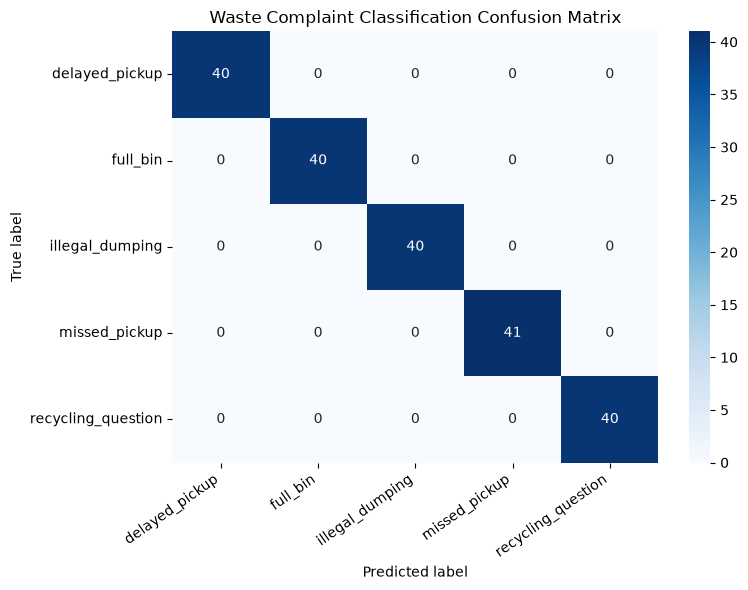

In [7]:
confusion = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Waste Complaint Classification Confusion Matrix")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Save the Trained Model

The saved object includes both the TF-IDF vectorizer and Logistic Regression classifier, so new text can be passed directly to `model.predict`.

In [24]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(model, MODEL_PATH)
print(f"Saved model to: {MODEL_PATH.resolve()}")

Saved model to: C:\Users\Hp\Desktop\tekher\Isuku-Models\model\waste_complaint_classifier.joblib


## Try the Classifier

In [25]:
sample_complaints = [
    "It has been weeks since they picked the waste materials here in Nyarugenge. Can you please send someone?",
    "Our rubbish has not been collected this week.",
    "There is a huge pile of rubbish dumped next to the road.",
    "Where can I recycle plastic bottles?",
    "The communal bin is completely full.",
    "The collectors came two days late.",
]

sample_predictions = pd.DataFrame({
    "complaint": sample_complaints,
    "predicted_category": model.predict([clean_text(text) for text in sample_complaints]),
})
display(sample_predictions)

,complaint,predicted_category
0,It has been weeks since they picked the waste ...,missed_pickup
1,Our rubbish has not been collected this week.,missed_pickup
2,There is a huge pile of rubbish dumped next to...,illegal_dumping
3,Where can I recycle plastic bottles?,recycling_question
4,The communal bin is completely full.,full_bin
5,The collectors came two days late.,delayed_pickup
